# Credit Card Defaulting & Approvals.
### Dataset in use: UCI credit card

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_flag
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Class Distribution (%):
default_flag
0    77.88
1    22.12
Name: proportion, dtype: float64


/var/folders/ff/v2dldfbj3jdg78mx32h50bzr0000gq/T/ipykernel_27555/3744380696.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='default_flag', palette='Set2')


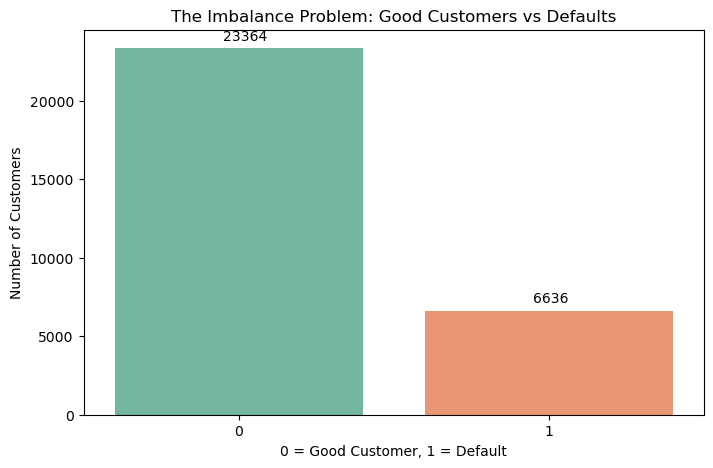

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('./default_of_credit_card_clients.csv')

# 1. Quick Sanity Check
display(df.head())

# 2. The Imbalance Reality Check
df = df.rename(columns={'default payment next month': 'default_flag'})

display(df.head())
default_rates = df['default_flag'].value_counts(normalize=True) * 100
print("Class Distribution (%):")
print(default_rates)

# 3. Visualize it for the README
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='default_flag', palette='Set2')
plt.title('The Imbalance Problem: Good Customers vs Defaults')
plt.xlabel('0 = Good Customer, 1 = Default')
plt.ylabel('Number of Customers')

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 500))

plt.show()

## Calculating Baseline cost

In [3]:
# (fn * 50000)
# (no.of bad customers who default * 50k)

classes = df['default_flag'].value_counts()
no_of_bad_customers = int(classes[1])
baseline_cost = (no_of_bad_customers * 50000)
baseline_cost

331800000

### If bank approves everyone and 22.1% (6636) have actually defaulted, it costs bank around 33.18 crores in loss due to 6636 defaulters.

In [4]:
import numpy as np
import pandas as pd

## Important Formulae

### ![Formulae](./Formulae.png)

## L2 Regularisation

### ![Visual Math L2 eauation](./L2_reg_equation.png)

## After calculating derviation ... since updating gradients mean taking derivatives,

### ![Visual Math L2 eauation](./after_differentiation_L2_equation.png)
### ![Visual Math L2 eauation](./after_differentiation_L2_equation_final.png)

In [5]:
# class CustomLogisticRegression:
#     """
#     Logistic Regression from scratch with L2 Regularization and Class Weights.
#     """
    
#     def __init__(self, epochs=1000, lr=0.01, lambda_param=0.1, class_weights=None):
#         self.epochs = epochs
#         self.lr = lr
#         self.lambda_param = lambda_param
#         self.class_weights = class_weights
#         self.w = None
#         self.b = None
#         self.loss_history = []

#     def _sigmoid(self, y):

#         # clipping to a range of -500 to 500 to prevent overflow errors on exponent.
#         y = np.clip(y, -500, 500)
#         return 1 / (1 + np.exp(-y))

#     def _binary_cross_entropy(self, y_true, y_pred, sample_weights):
        
#         # add epsilon to prevent log(0) error
#         epsilon = 1e-15

#         y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        
#         loss = -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        
#         weighted_loss = loss * sample_weights

#         # calculate Regularisation loss
#         # formula: Actual formula before differentiation as described in previous cell
#         L2 = (self.lambda_param / (2 * len(y_true))) * np.sum(np.square(self.w))

#         # add and return 
#         return np.mean(weighted_loss) + L2

#     def fit(self, X, y):

#         # make sure X and y are np arrays
#         X = np.array(X)
#         y = np.array(y)
        
#         n_samples, n_features = X.shape
#         self.w = np.zeros(n_features)
#         self.b = 0

#         # compute sample_wieghts
#         sample_weights = np.ones(n_samples)
#         if self.class_weights:
#             for class_label, weight in self.class_weights.items():
#                 sample_weights[y == class_label] = weight

#         for _ in range(self.epochs):

#             # y = mx + c
#             y_pred = np.dot(X, self.w) + self.b

#             # pass throught sigmoid to get probabilities between 0 to 1.
#             y_probs = self._sigmoid(y_pred)

#             # calcualte loss
#             loss = self._binary_cross_entropy(y, y_probs, sample_weights)
#             self.loss_history.append(loss)

#             # compute error
#             err = (y_probs - y) * sample_weights

#             # update gradients
#             # updating weights matrices with L2 penalty
#             # Differentiation of dL2/dw
#             dw = (1 / n_samples) * np.dot(X.T, err) + (self.lambda_param / n_samples) * self.w
#             db = (1 / n_samples) * np.sum(err)
            
#             self.w -= self.lr * dw
#             self.b -= self.lr * db

#     def _predict_proba(self, X):
#         # for given example perform dot product with trained weights and bias
#         y_pred = np.dot(X, self.w) + self.b
#         # squeeze the probs through sigmoid function
#         y_probs = self._sigmoid(y_pred)

#         # sigmoid returns probabiities of defaulters a 1-D array. We construct class "0" and but subtracting 1 from class "1"
#         return np.vstack((1 - y_probs, y_probs)).T

#     def _predict(self, X, threshold=0.5):
#         # compute probabilities
#         probabilities = self._predict_proba(X)[:, 1]
#         # return if greater than agreed threshold
#         return (probabilities >= threshold)
    

# Importing <i>CustomLogisticRegression</i> Model from <i>custom_logistic_regression.py</i> file

In [6]:
import sys

sys.path.append('./src')

from custom_logistic_regression import CustomLogisticRegression

### Testing the model

In [7]:
# first we gonna do some imports 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_flag
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Perform some data cleansing

In [9]:
df.drop(columns=['ID'], inplace=True)
display(df)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_flag
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [10]:
y = df.pop('default_flag')

In [11]:
y

0        1
1        1
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    1
29998    1
29999    1
Name: default_flag, Length: 30000, dtype: int64

In [12]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [13]:
X = df.to_numpy()
y = y.values.reshape(-1, 1) # you know y
X, y

(array([[ 20000,      2,      2, ...,      0,      0,      0],
        [120000,      2,      2, ...,   1000,      0,   2000],
        [ 90000,      2,      2, ...,   1000,   1000,   5000],
        ...,
        [ 30000,      1,      2, ...,   4200,   2000,   3100],
        [ 80000,      1,      3, ...,   1926,  52964,   1804],
        [ 50000,      1,      2, ...,   1000,   1000,   1000]],
       shape=(30000, 23)),
 array([[1],
        [1],
        [0],
        ...,
        [1],
        [1],
        [1]], shape=(30000, 1)))

### _Split First, Scale later ..._
#### **_I repeat,_**
### _Split First, Scale later._

In [14]:
# Split first, scale later to prevent leakage of data to test_data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41, stratify=y)

X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0)

# u shall use same mean and std of training data to scale test data as well.
X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

print(f'Training data shapes: \n\nX_train_scaled = {X_train_scaled}, \n\ny_train = {y_train}')

Training data shapes: 

X_train_scaled = [[ 3.17825777  0.81500899 -1.07970679 ...  0.07344931  0.06528383
   0.03955022]
 [ 0.24965572  0.81500899  0.18538929 ... -0.30523973 -0.31217984
  -0.29541373]
 [ 1.02034047  0.81500899 -1.07970679 ... -0.19641234 -0.26786276
   6.2631422 ]
 ...
 [ 2.17636759  0.81500899 -1.07970679 ... -0.30523973 -0.03539023
  -0.29541373]
 [-0.36689208 -1.22698033 -1.07970679 ... -0.30523973 -0.31217984
  -0.29541373]
 [ 0.3267242   0.81500899 -1.07970679 ... -0.30523973 -0.31217984
   1.72755223]], 

y_train = [[0]
 [0]
 [0]
 ...
 [0]
 [1]
 [0]]


In [15]:
y_train = y_train.flatten()
y_train

array([0, 0, 0, ..., 0, 1, 0], shape=(24000,))

### Calling the model

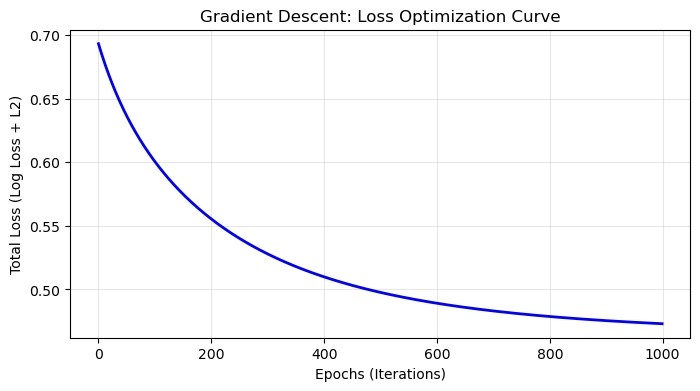

In [16]:
# custom_model = CustomLogisticRegression(epochs=1000, lr=0.01, lambda_param=1.0, class_weights={0 : 1.0, 1 : 4.0})
# removing the class weights as they are inflating the probabilities for no much reason. We are calculating optimal threshold anyways later
custom_model = CustomLogisticRegression(epochs=1000, lr=0.01, lambda_param=1.0, class_weights=None)
custom_model.fit(X_train_scaled, y_train)

# 3. Plot the mathematical proof
plt.figure(figsize=(8, 4))
plt.plot(custom_model.loss_history, color='blue', linewidth=2)
plt.title('Gradient Descent: Loss Optimization Curve')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Total Loss (Log Loss + L2)')
plt.grid(True, alpha=0.3)
plt.show()

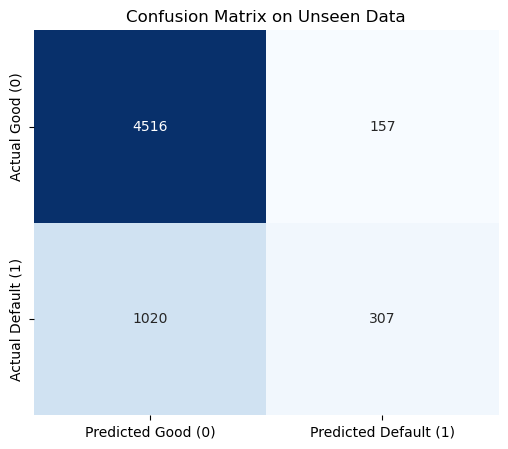


Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.97      0.88      4673
           1       0.66      0.23      0.34      1327

    accuracy                           0.80      6000
   macro avg       0.74      0.60      0.61      6000
weighted avg       0.78      0.80      0.76      6000



In [17]:
# 1. Test with Test_data
predictions = custom_model._predict(X_test_scaled, threshold=0.50)

# 2. Plot the Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Good (0)', 'Predicted Default (1)'],
            yticklabels=['Actual Good (0)', 'Actual Default (1)'])
plt.title('Confusion Matrix on Unseen Data')
plt.show()

# 3. Print the standard business metrics
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

In [18]:
custom_model.w, custom_model.b

(array([-0.07401589, -0.04381614, -0.03830643, -0.06243798,  0.05074502,
         0.39984665,  0.14783142,  0.09483114,  0.06824585,  0.04374902,
         0.03364154, -0.04831626, -0.0287919 , -0.02605918, -0.01134972,
        -0.00830751, -0.00193569, -0.07329682, -0.0608379 , -0.02886552,
        -0.06486721, -0.03832673, -0.02648908]),
 np.float64(-1.1435412399654987))

## 2. Fixing the model

## Data Engineering: Adding addtional columns
1. utilisation,
2. pay_to_bill ration
3. delinquency score,

#### _**Utilisation**: A person with high cred_limit and less utilisation is more safe than one who maxes out there utilisation. We need to carefully_
#### default those customers
### given as: Avg. of bill_amt / cred_limit

#### _**pay_to_bill ratio**: measure to customer's bill, how much they actually paid off?_
### given as: _sum(pay_amt_1, pay_amt_2 .. pay_amt_n) / sum(bill_amt_1, bill_amt_2 ... bill_amt_n) **be careful of divide by zero**_

#### _**Delinquency score**: -1, 0 means they paid on time. 1, 2, 3 ... means bill payment delayed those many months._
### sum(pay_1, pay_2 .. pay_n)

In [19]:
df = pd.read_csv('./default_of_credit_card_clients.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [20]:
df.rename(columns={'default payment next month' : 'default_flag'}, inplace=True)
df.drop(columns=['ID'], inplace=True)
y = df.pop('default_flag')
y

0        1
1        1
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    1
29998    1
29999    1
Name: default_flag, Length: 30000, dtype: int64

In [21]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [22]:
billing_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4','BILL_AMT5', 'BILL_AMT6']
payment_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

df['utilisation_ratio'] = np.clip(df[billing_cols].mean(axis=1) / df['LIMIT_BAL'], 0, None)

# 2. pay_to_bill ratio
df['payment_sum'] = df[payment_cols].sum(axis=1)
df['billing_sum'] = df[billing_cols].sum(axis=1)

df['payment_to_bill_ratio'] = np.where(df['billing_sum'] > 0, 
                                       df['payment_sum'] / df['billing_sum'], 
                                       1.0)

df['payment_to_bill_ratio'] = np.clip(df['payment_to_bill_ratio'], 0, 1.0)

# 3. Delinquency score
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

delinquency_clipped = df[pay_cols].clip(lower=0)
df['delinquency_score'] = delinquency_clipped.sum(axis=1)

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,utilisation_ratio,payment_sum,billing_sum,payment_to_bill_ratio,delinquency_score
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,0.064200,689,7704,0.089434,4
1,120000,2,2,2,26,-1,2,0,0,0,...,1000,1000,1000,0,2000,0.023718,5000,17077,0.292791,4
2,90000,2,2,2,34,0,0,0,0,0,...,1500,1000,1000,1000,5000,0.188246,11018,101653,0.108388,0
3,50000,2,2,1,37,0,0,0,0,0,...,2019,1200,1100,1069,1000,0.771113,8388,231334,0.036259,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,36681,10000,9000,689,679,0.364463,59049,109339,0.540054,0


## Dropping temporary columns

In [23]:
df = df.drop(columns=['payment_sum', 'billing_sum'])
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,utilisation_ratio,payment_to_bill_ratio,delinquency_score
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,689,0,0,0,0,0.064200,0.089434,4
1,120000,2,2,2,26,-1,2,0,0,0,...,3261,0,1000,1000,1000,0,2000,0.023718,0.292791,4
2,90000,2,2,2,34,0,0,0,0,0,...,15549,1518,1500,1000,1000,1000,5000,0.188246,0.108388,0
3,50000,2,2,1,37,0,0,0,0,0,...,29547,2000,2019,1200,1100,1069,1000,0.771113,0.036259,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,19131,2000,36681,10000,9000,689,679,0.364463,0.540054,0


In [24]:
# dropping unnecessary columns. If left behind, the weights matrix will be of dimensions (26, 1). User can't input 26 values from frontend
# to do the prediciton. Hence stripping away, pay_amt, pay_n, bill_n cols for simplicity.
## I wonder if training those cols is needed tho.

drop_cols = [col_name for col_name in df.columns if 'PAY_AMT' in col_name or 'PAY_' in col_name or 'BILL_AMT' in col_name]

In [25]:
drop_cols

['PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

In [26]:
df = df.drop(columns=drop_cols)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,utilisation_ratio,payment_to_bill_ratio,delinquency_score
0,20000,2,2,1,24,0.064200,0.089434,4
1,120000,2,2,2,26,0.023718,0.292791,4
2,90000,2,2,2,34,0.188246,0.108388,0
3,50000,2,2,1,37,0.771113,0.036259,0
4,50000,1,2,1,57,0.364463,0.540054,0


## Re-training the model with updated

In [27]:
X = df.to_numpy()
y = y.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0)

X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

X_train_scaled.shape, y_train.shape

((24000, 8), (24000,))

In [28]:
X, y

(array([[2.00000000e+04, 2.00000000e+00, 2.00000000e+00, ...,
         6.42000000e-02, 8.94340602e-02, 4.00000000e+00],
        [1.20000000e+05, 2.00000000e+00, 2.00000000e+00, ...,
         2.37180556e-02, 2.92791474e-01, 4.00000000e+00],
        [9.00000000e+04, 2.00000000e+00, 2.00000000e+00, ...,
         1.88246296e-01, 1.08388341e-01, 0.00000000e+00],
        ...,
        [3.00000000e+04, 1.00000000e+00, 2.00000000e+00, ...,
         3.91644444e-01, 4.43996823e-01, 9.00000000e+00],
        [8.00000000e+04, 1.00000000e+00, 3.00000000e+00, ...,
         5.55439583e-01, 5.52043989e-01, 1.00000000e+00],
        [5.00000000e+04, 1.00000000e+00, 2.00000000e+00, ...,
         7.69580000e-01, 3.59849961e-02, 0.00000000e+00]], shape=(30000, 8)),
 array([1, 1, 0, ..., 1, 1, 1], shape=(30000,)))

In [29]:
# model = CustomLogisticRegression(epochs=1500, lr=0.01, lambda_param=0.1, class_weights={0 : 1.0, 1 : 4.0})
'''Note:
removing the class weights as they are inflating the probabilities for no much reason. We are calculating optimal threshold anyways later
1. penalising model with 3x more for missing defaulters, we need to keep the threshold while predicting results for test data to be less
than 17.
2. If class_wights are not be used, then threshold need to be set to 50.

This is due to the problem of "Double Dipping". Penalising the model with class_weights will increase the probability of defaulter to be
reaching near 50%. If threshold is somewhere around 17, the model rejects almost everyone. Hence, only one among the following shall be 
active at a time.

1. Active class_weights - Threshold: 50
2. Inactive class_weights - Threshold: optimal_threshold.

'''
model = CustomLogisticRegression(epochs=1500, lr=0.01, lambda_param=0.1, class_weights=None)

y_train = y_train.flatten() # flattening array as required for model
model.fit(X_train_scaled, y_train)

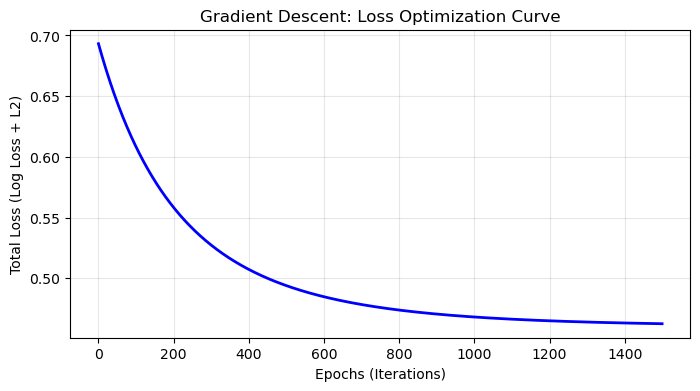

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='blue', linewidth=2)
plt.title('Gradient Descent: Loss Optimization Curve')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Total Loss (Log Loss + L2)')
plt.grid(True, alpha=0.3)
plt.show()

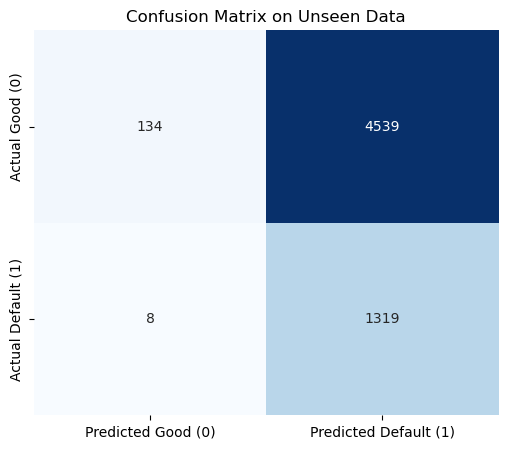


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.03      0.06      4673
           1       0.23      0.99      0.37      1327

    accuracy                           0.24      6000
   macro avg       0.58      0.51      0.21      6000
weighted avg       0.78      0.24      0.12      6000



In [31]:
# 1. Test with Test_data
'''
Note: 

Threshold 0.50 if class_weights are not being used.
Threshold 0.11 if class_weights are being used. # as calculated frmo the 
'''
# predictions = model._predict(X_test_scaled, threshold=0.50)
predictions = model._predict(X_test_scaled, threshold=0.11)

# 2. Plot the Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Good (0)', 'Predicted Default (1)'],
            yticklabels=['Actual Good (0)', 'Actual Default (1)'])
plt.title('Confusion Matrix on Unseen Data')
plt.savefig('confusion_matrix_after_data_engineering.png')
plt.show()

# 3. Print the standard business metrics
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

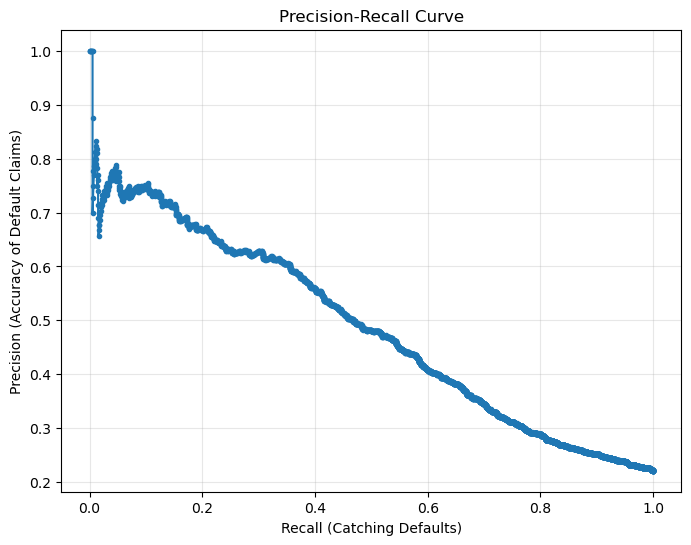

In [32]:
from sklearn.metrics import precision_recall_curve

# Get raw probabilities 
y_scores = model._predict_proba(X_test_scaled)[:, 1]

# Calculate PR curve data
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Plot it
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='Custom Model (Engineered Features)')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall (Catching Defaults)')
plt.ylabel('Precision (Accuracy of Default Claims)')
plt.grid(True, alpha=0.3)
plt.savefig('preicison_recall_curve.png', dpi=300)
plt.show()

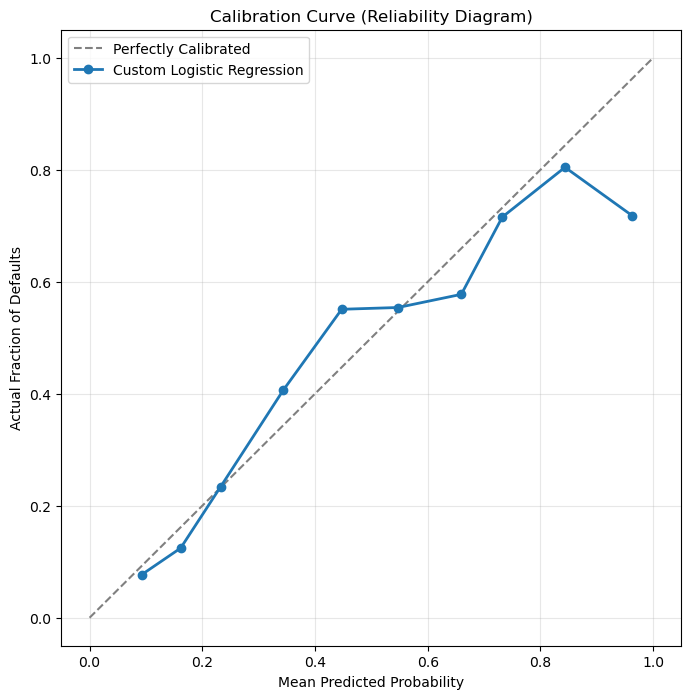

In [33]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# 1. Get the raw probabilities for the test set. 0th col: probability of class 0, 1st col: probability of class 1 (will default)
y_probs = model._predict_proba(X_test_scaled)[:, 1]

# 2. Calculate the calibration curve (split into 10 buckets)
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

# 3. Plot it
plt.figure(figsize=(8, 8))

# Plot the perfectly calibrated line (What we want)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

# Plot our model's actual calibration
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Custom Logistic Regression')

plt.title('Calibration Curve (Reliability Diagram)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Actual Fraction of Defaults')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('model_reliability_diagram.png', dpi=300)
plt.show()

## 3. Scorecard logic for CIBIL like output

In [34]:
class ScorecardTransformer:

    def __init__(self, pdo = 20, baseline_score = 600, baseline_odds = 2):
        self.factor = pdo/np.log(2)
        self.offset = baseline_score - self.factor * np.log(baseline_odds)

    def transform(self, y_probs):
        probabilities = np.clip(y_probs, 1e-10, 1 - 1e-10)
        odds_good = (1 - probabilities) / probabilities

        scores = self.offset + self.factor * np.log(odds_good)

        return np.clip(np.round(scores), 350, 850).astype(int)

In [35]:
cibil_score = ScorecardTransformer()
cibil_score.transform(y_probs)

array([617, 620, 619, ..., 627, 623, 628], shape=(6000,))

## 4. Proving 0.5 Threshold is wrong. The Loop

In [36]:
# Raw probabilities in 
y_probs

array([0.2177799 , 0.20002555, 0.20616894, ..., 0.16576947, 0.18510263,
       0.1594008 ], shape=(6000,))

In [37]:
# lets make a few thresholds from 0.1 to 0.99
thresholds = np.linspace(0.01, 0.99, 100)
business_costs = []

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)

    # To get fp, fn (type-I and type-II) errors,
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # business loses money to 2000$ per fp and 50000$ per fn
    cost = (fp * 2000) + (fn * 50000)
    business_costs.append(cost)

In [38]:
min_cost = min(business_costs)
min_cost

np.int64(9322000)

In [39]:
optimal_threshold = thresholds[business_costs.index(min_cost)]
cost_at_50 = business_costs[np.abs(thresholds - 0.50).argmin()]

# Comparison of how much the bank would lose at 50% threshold than calculated optimal threshold

In [40]:
min_cost, cost_at_50

(np.int64(9322000), np.int64(51246000))

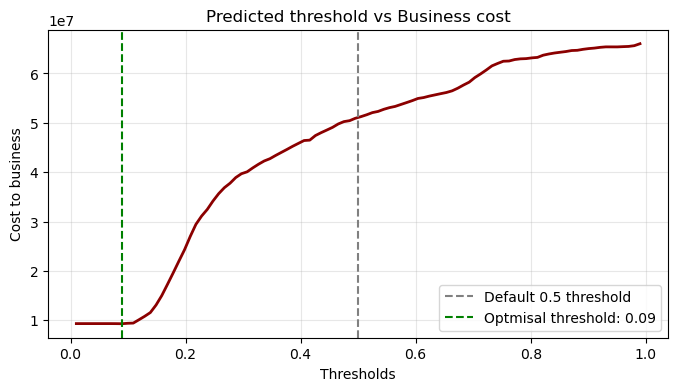

In [41]:
plt.figure(figsize=(8, 4))
plt.plot(thresholds, business_costs, linewidth=2, color='darkred')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default 0.5 threshold')
plt.axvline(x = optimal_threshold, color = 'green', linestyle='--', label=f'Optmisal threshold: {optimal_threshold:.2f}')

plt.title('Predicted threshold vs Business cost')
plt.xlabel('Thresholds')
plt.ylabel('Cost to business')

plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('predicted_optimal_threshold.png', dpi=300)
plt.show()

# 5. Introducing profit
#### if a good customer brings 5000$ over years as profit then rejecting is 2k + 5k = 7k business loss

In [42]:
# The new financial reality
PROFIT_PER_GOOD = 5000
LOSS_PER_DEFAULT = 50000

thresholds = np.linspace(0.01, 0.99, 100)
business_profits = []

# Remember to use the raw probabilities from your unweighted model!
y_probs = model._predict_proba(X_test_scaled)[:, 1]

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)
    
    # Unpack the matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Calculate the Total Net Profit for the bank at this specific threshold
    total_profit = (tn * PROFIT_PER_GOOD) - (fn * LOSS_PER_DEFAULT)
    business_profits.append(total_profit)

# Find the threshold that makes the bank the MOST money
max_profit = max(business_profits)
new_optimal_threshold = thresholds[business_profits.index(max_profit)]

print(f"Optimal Threshold for Maximum Profit: {new_optimal_threshold:.2f}")
print(f"Maximum Projected Profit: ${max_profit:,}")

Optimal Threshold for Maximum Profit: 0.11
Maximum Projected Profit: $260,000


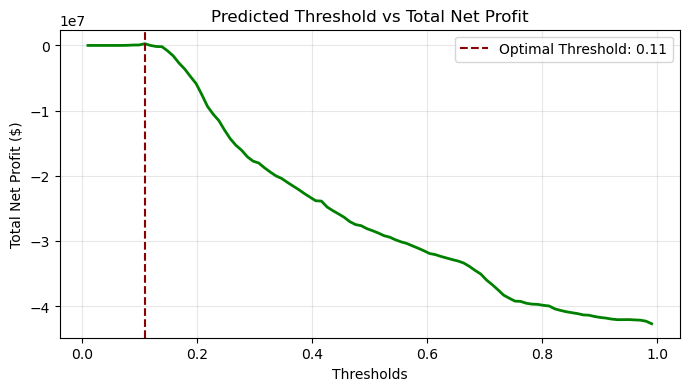

In [45]:
plt.figure(figsize=(8, 4))
plt.plot(thresholds, business_profits, linewidth=2, color='green')
plt.axvline(x=new_optimal_threshold, color='darkred', linestyle='--', label=f'Optimal Threshold: {new_optimal_threshold:.2f}')
plt.title('Predicted Threshold vs Total Net Profit')
plt.xlabel('Thresholds')
plt.ylabel('Total Net Profit ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('new_threshold_vs_net_profit.png', dpi=300)
plt.show()

## 6. Exporting model, trained mean and std

In [44]:
import pickle

data = {
        "model": model,
        "training_mean": X_train_mean,
        "training_std": X_train_std
    }

with open('./credit_risk_model.pkl', 'wb') as file:
    pickle.dump(data, file)

print("Custom Model, Mean, and Standard Deviation successfully exported!")

Custom Model, Mean, and Standard Deviation successfully exported!


# _Further Improvements_

#### Logistic regression is a linear model. Trying to fit a straight line to seperate bad cusomters from good ones doesn't improve by adding more features

### **Best models to use:**
### **XG_Boost or Tree based algorithms**

#### Instead of drawing a single straight line, these models build hundreds of decision trees that can naturally slice the data into complex, non-linear geometric shapes.

#### If you passed this exact same dataset into XGBoost, you would see the PR curve physically shift closer to the top-right corner without engineering any additional features.